<a href="https://colab.research.google.com/github/AJasa1983/Assessment_Repo/blob/main/programmng_for_Data_Analysis_st20350980.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SETTING UP THE ENVIRONMENT
#importing Libraries and Connect to Github

In [1]:
# ── IMPORT THE NECCESSARY LIBARIES
import plotly.io as pio # ADDED THIS LIBRARY FOR SOME VISUALIZATION CHART TO SHOW
pio.renderers.default = "colab"
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
# GITHUB SETUP
# this is for making commits
! git config --global user.name "AJasa1983"
! git config --global user.email "ofemomini60@gmail.com"

# GitHub credentials
username = "AJasa1983"
repo     = "Assessment_Repo"

import os
if not os.path.exists(repo):
    os.system(f'git clone https://github.com/{username}/{repo}')
    print(f'Cloned {repo} successfully.')
else:
    print(f'{repo} already exists — skipping clone.')

%cd {repo}
print('Working directory:', os.getcwd())

Cloned Assessment_Repo successfully.
/content/Assessment_Repo
Working directory: /content/Assessment_Repo


MERGING THE CSV FILES

In [3]:
# LOADING & MERGING DATA
# glob.glob finds all CSV files in the current directory
city_files = glob.glob('*.csv')
print(f'CSV files found: {city_files}')


all_data = []
for f in city_files:
    temp = pd.read_csv(f)
    all_data.append(temp)
    print(f'  Loaded {f} — {len(temp):,} rows')

df = pd.concat(all_data, ignore_index=True)

print(f'\nMerged dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')

CSV files found: ['PRSA_Data_Shunyi_20130301-20170228.csv', 'PRSA_Data_Huairou_20130301-20170228.csv', 'PRSA_Data_Tiantan_20130301-20170228.csv', 'PRSA_Data_Dongsi_20130301-20170228.csv']
  Loaded PRSA_Data_Shunyi_20130301-20170228.csv — 35,064 rows
  Loaded PRSA_Data_Huairou_20130301-20170228.csv — 35,064 rows
  Loaded PRSA_Data_Tiantan_20130301-20170228.csv — 35,064 rows
  Loaded PRSA_Data_Dongsi_20130301-20170228.csv — 35,064 rows

Merged dataset: 140,256 rows x 18 columns


DATA UNERSTANDING

Before any Analysis, we need to understand what the Datasets looks like.
1. How many Eows and columns does it have?
2. What are the Data types of each column?
3. Are there any missing values we need to handle?
4. Statistical details about the ranges and distribution

In [4]:
# ROWS & COLUMNS

print('=' * 55)
print(f'  Total Rows    : {df.shape[0]:,}')
print(f'  Total Columns : {df.shape[1]}')
print('=' * 55)

# This is the list of all column names so that we know what variables are available.........
print('\nColumn Names:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col}')

  Total Rows    : 140,256
  Total Columns : 18

Column Names:
   1. No
   2. year
   3. month
   4. day
   5. hour
   6. PM2.5
   7. PM10
   8. SO2
   9. NO2
  10. CO
  11. O3
  12. TEMP
  13. PRES
  14. DEWP
  15. RAIN
  16. wd
  17. WSPM
  18. station


In [5]:
# DATA TYPES

print('Column Data Types:')
print(df.dtypes)

print('\nFirst 15 rows of data:')
display(df.head(15))

Column Data Types:
No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd          object
WSPM       float64
station     object
dtype: object

First 15 rows of data:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,3.0,8.0,300.0,44.0,-0.9,1025.8,-20.5,0.0,NW,9.3,Shunyi
1,2,2013,3,1,1,12.0,12.0,3.0,7.0,300.0,47.0,-1.1,1026.1,-21.3,0.0,NW,9.4,Shunyi
2,3,2013,3,1,2,14.0,14.0,NaN,7.0,200.0,22.0,-1.7,1026.2,-23.0,0.0,NW,8.6,Shunyi
3,4,2013,3,1,3,12.0,12.0,3.0,5.0,NaN,NaN,-2.1,1027.3,-23.3,0.0,NW,6.6,Shunyi
4,5,2013,3,1,4,12.0,12.0,3.0,NaN,200.0,11.0,-2.4,1027.7,-22.9,0.0,NW,4.5,Shunyi
5,6,2013,3,1,5,11.0,11.0,3.0,7.0,200.0,45.0,-2.8,1028.2,-22.1,0.0,NNW,1.7,Shunyi
6,7,2013,3,1,6,12.0,12.0,3.0,9.0,300.0,74.0,-4.0,1029.0,-21.2,0.0,NNE,1.6,Shunyi
7,8,2013,3,1,7,13.0,13.0,3.0,23.0,300.0,59.0,-2.4,1030.5,-21.3,0.0,NE,1.7,Shunyi
8,9,2013,3,1,8,8.0,8.0,3.0,19.0,400.0,66.0,-1.0,1031.2,-21.8,0.0,NNW,2.7,Shunyi
9,10,2013,3,1,9,3.0,6.0,3.0,21.0,400.0,60.0,0.0,1031.3,-22.9,0.0,SSW,0.8,Shunyi


Columns with Missing Values:


,Missing Count,Missing %
CO,7923,5.65
NO2,5349,3.81
O3,4147,2.96
SO2,4057,2.89
PM2.5,3293,2.35
PM10,2475,1.76
wd,941,0.67
TEMP,142,0.10
PRES,144,0.10
DEWP,147,0.10


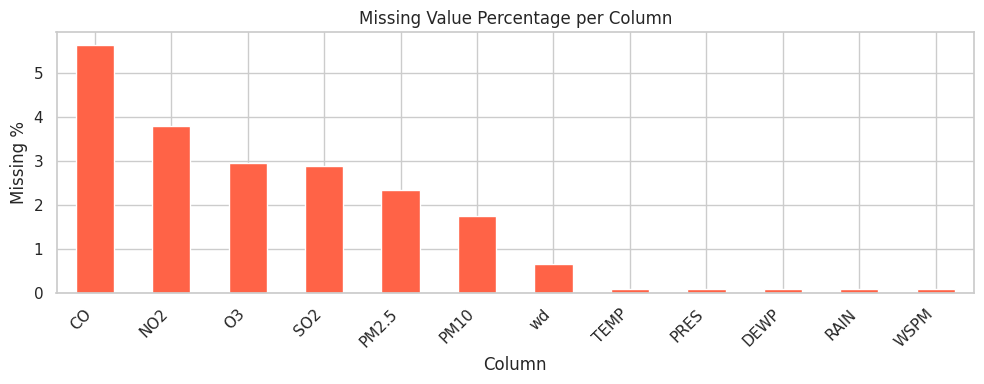

In [6]:
# MISSING VALUES

missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count' : missing_count,
    'Missing %'     : missing_pct
})

# THIS IS ONLY (showing columns that actually have missing values)
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('Columns with Missing Values:')
display(missing_report)

missing_report['Missing %'].plot(
    kind='bar', figsize=(10, 4), color='tomato', edgecolor='white'
)
plt.title('Missing Value Percentage per Column')
plt.xlabel('Column')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

MISSING VALUE PERCENTAGE PER COLUMN

OBSERVATIONS

The merged dataset comprises 140,256 hourly observations drawn from four monitoring stations covering the period 2013 to 2017. Each station contributes an equal share of 35,064 records, confirming that the data is uniformly distributed across all locations with no station over- or under-represented.
Examining the variables, the pollutant measurements — PM2.5, PM10, SO2, NO2, CO, and O3 — alongside the meteorological readings of temperature (TEMP), pressure (PRES), dew point (DEWP), rainfall (RAIN), and wind speed (WSPM) — all show some degree of missing data, though the proportion varies from column to column.
With respect to PM2.5 specifically, the recorded maximum value is considerably higher than the bulk of the distribution, pointing to periodic pollution spikes that manifest as outliers in the data. In terms of temporal coverage, the year variable spans 2013 through to 2017, while the hour variable runs from 0 to 23, confirming that measurements were taken at an hourly resolution throughout the entire study period.
Finally, the wind direction column (WD) holds categorical string values rather than numbers, making it distinct from every other variable in the dataset, all of which are stored as numeric types.



In [7]:
# STATISTICAL SUMMARY

print('Statistical Summary of Numeric Columns:')
display(df.describe().round(2))

# HOW MANY RECORDS DOES EACH STATION HAVE?
print('\nRecord Count per Station:')
print(df['station'].value_counts())

Statistical Summary of Numeric Columns:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,140256.00,140256.00,140256.00,140256.00,140256.00,136963.00,137781.00,136199.00,134907.00,132333.00,136109.00,140114.00,140112.00,140109.00,140110.00,140135.00
mean,17532.50,2014.66,6.52,15.73,11.50,79.39,101.75,14.66,45.86,1208.21,57.06,13.29,1011.44,2.40,0.06,1.80
std,10122.14,1.18,3.45,8.80,6.92,80.42,90.54,20.58,32.15,1115.95,56.72,11.55,10.42,13.85,0.80,1.27
min,1.00,2013.00,1.00,1.00,0.00,2.00,2.00,0.29,1.03,100.00,0.21,-19.90,982.80,-43.40,0.00,0.00
25%,8766.75,2014.00,4.00,8.00,5.75,20.00,34.00,2.00,21.00,500.00,12.00,3.00,1003.00,-9.00,0.00,1.00
50%,17532.50,2015.00,7.00,16.00,11.50,55.00,80.00,6.00,39.00,900.00,45.00,14.30,1011.00,3.00,0.00,1.50
75%,26298.25,2016.00,10.00,23.00,17.25,111.00,141.00,18.00,64.00,1500.00,81.00,23.10,1019.70,15.10,0.00,2.30
max,35064.00,2017.00,12.00,31.00,23.00,941.00,999.00,315.00,258.00,10000.00,1071.00,41.10,1042.80,29.10,46.40,12.90



Record Count per Station:
station
Shunyi     35064
Huairou    35064
Tiantan    35064
Dongsi     35064
Name: count, dtype: int64


DATA PREPROCESSING

In this Section we will;
* Create a datetime column - combines year/month/day/hour into one proper     timestamp
* Remove duplicates - Avoid double-counting rows
* Handle missing values _ fills gaps using forwardf - fill (last known value) per station
* Feature engineering - Add useful new columns season, AQI category.

NOTE:
These steps ensures the data is clean, consistent and enriched for Analysis

In [8]:
# CREATE DATETIME COLUMN

df['datetime'] = pd.to_datetime(
    df[['year', 'month', 'day', 'hour']]
)

# Set datetime as the index — THIS IS USEFUL FOR TIME-SERIES OPERATIONS
df = df.sort_values('datetime').reset_index(drop=True)

print('Datetime column sample:')
print(df[['year','month','day','hour','datetime']].head(3))
print(f'\nDate range: {df["datetime"].min()} → {df["datetime"].max()}')

Datetime column sample:
   year  month  day  hour   datetime
0  2013      3    1     0 2013-03-01
1  2013      3    1     0 2013-03-01
2  2013      3    1     0 2013-03-01

Date range: 2013-03-01 00:00:00 → 2017-02-28 23:00:00


In [9]:
# REMOVING DUPLICATES


before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
after = len(df)

print(f'Rows before deduplication : {before:,}')
print(f'Rows after  deduplication : {after:,}')
print(f'Duplicates removed        : {before - after}')

Rows before deduplication : 140,256
Rows after  deduplication : 140,256
Duplicates removed        : 0


In [10]:
# HANDLE MISSING VALUES ─

numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
                'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

df[numeric_cols] = (
    df.groupby('station')[numeric_cols]
      .transform(lambda x: x.ffill().bfill())
)

# Confirming that missing values are fully resolved
remaining = df[numeric_cols].isnull().sum()
print('Missing values remaining after fill:')
print(remaining[remaining > 0] if remaining.sum() > 0 else 'None — all filled!')

Missing values remaining after fill:
None — all filled!


In [11]:
# FEATURE ENGINEERING — SEASON

season_map = {
    12: 'Winter', 1: 'Winter',  2: 'Winter',
     3: 'Spring', 4: 'Spring',  5: 'Spring',
     6: 'Summer', 7: 'Summer',  8: 'Summer',
     9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}
df['season'] = df['month'].map(season_map)

print('Season distribution:')
print(df['season'].value_counts())

Season distribution:
season
Spring    35328
Summer    35328
Autumn    34944
Winter    34656
Name: count, dtype: int64


In [12]:
# AQI CATEGORY

def aqi_category(pm25):
    """Classify PM2.5 value into an AQI health category."""
    if pd.isna(pm25):        return 'Unknown'
    elif pm25 <= 12.0:       return 'Good'
    elif pm25 <= 35.4:       return 'Moderate'
    elif pm25 <= 55.4:       return 'Unhealthy for Sensitive Groups'
    elif pm25 <= 150.4:      return 'Unhealthy'
    elif pm25 <= 250.4:      return 'Very Unhealthy'
    else:                    return 'Hazardous'

df['AQI_Category'] = df['PM2.5'].apply(aqi_category)

print('AQI Category distribution:')
print(df['AQI_Category'].value_counts())

AQI Category distribution:
AQI_Category
Unhealthy                         48625
Moderate                          30663
Good                              21929
Unhealthy for Sensitive Groups    17836
Very Unhealthy                    15010
Hazardous                          6193
Name: count, dtype: int64


In [13]:
# FEATURE ENGINEERING — STATION TYPE

inner_stations = ['Dongsi', 'Tiantan']
df['station_type'] = df['station'].apply(
    lambda x: 'Inner (Urban)' if x in inner_stations else 'Outer (Suburban)'
)

print('Station type counts:')
print(df['station_type'].value_counts())

print('\nFinal dataset shape after preprocessing:', df.shape)
print('\nNew columns added: datetime, season, AQI_Category, station_type')
display(df[['datetime','station','station_type','season','AQI_Category','PM2.5']].head(5))

Station type counts:
station_type
Outer (Suburban)    70128
Inner (Urban)       70128
Name: count, dtype: int64

Final dataset shape after preprocessing: (140256, 22)

New columns added: datetime, season, AQI_Category, station_type


,datetime,station,station_type,season,AQI_Category,PM2.5
0,2013-03-01 00:00:00,Shunyi,Outer (Suburban),Spring,Good,3.0
1,2013-03-01 00:00:00,Huairou,Outer (Suburban),Spring,Good,7.0
2,2013-03-01 00:00:00,Tiantan,Inner (Urban),Spring,Good,6.0
3,2013-03-01 00:00:00,Dongsi,Inner (Urban),Spring,Good,9.0
4,2013-03-01 01:00:00,Huairou,Outer (Suburban),Spring,Good,4.0


STATISTICAL ANALYSIS & VISUALISATION

Right now the Data is clean, let's now explore it visually and statistically...

* Univariate: This examines each variable individual (distribution)
* Bivariate: explore relationships between pairs of variables (scatter plots, box plots)
* Multivariate: examines multi variables together (heatmaps, grouped bar charts, time series)

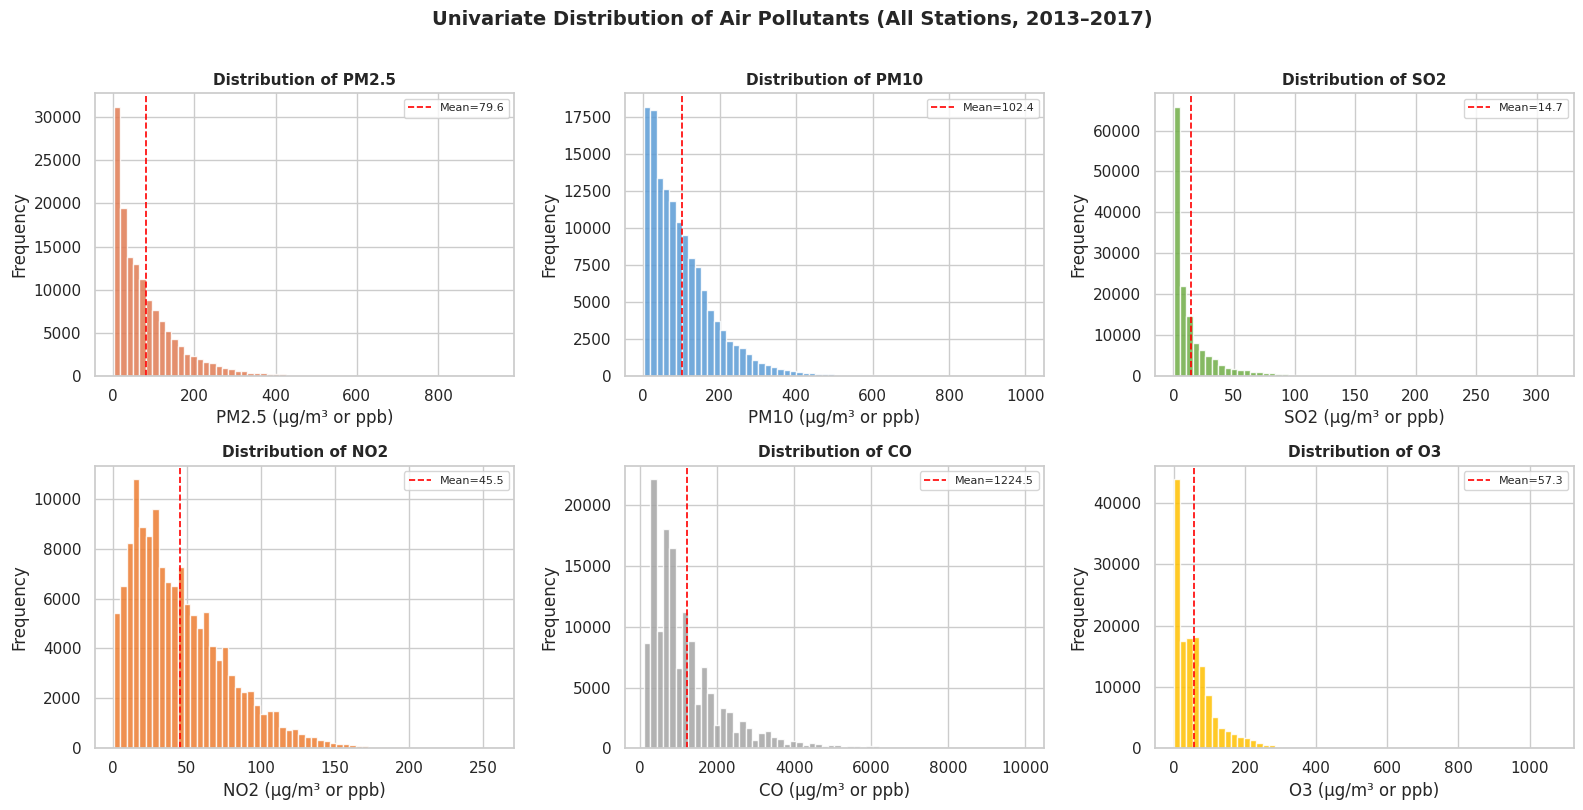

In [14]:
# UNIVARIATE — POLLUTANT DISTRIBUTIONS

pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

colors = ['#E07B54', '#5B9BD5', '#70AD47', '#ED7D31', '#A5A5A5', '#FFC000']

for i, col in enumerate(pollutants):
    axes[i].hist(df[col].dropna(), bins=60, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(f'{col} (µg/m³ or ppb)')
    axes[i].set_ylabel('Frequency')

    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.2, label=f'Mean={mean_val:.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Univariate Distribution of Air Pollutants (All Stations, 2013–2017)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_01_pollutant_distributions.png', bbox_inches='tight')
plt.show()



UNIVARIATE DISTRIBUTION OF AIR POLLUTANTS

(INTERPRETATION)

All pollutant distributions are rigt - skewed (long tail on the right).
This means that most readings are low, but there are occasional extreme spikes.
CO has the widest spread, reflecting its link to traffic and combustion.
O3 shows a more symmetric distribution, infliuenced by photochemical reactions.

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


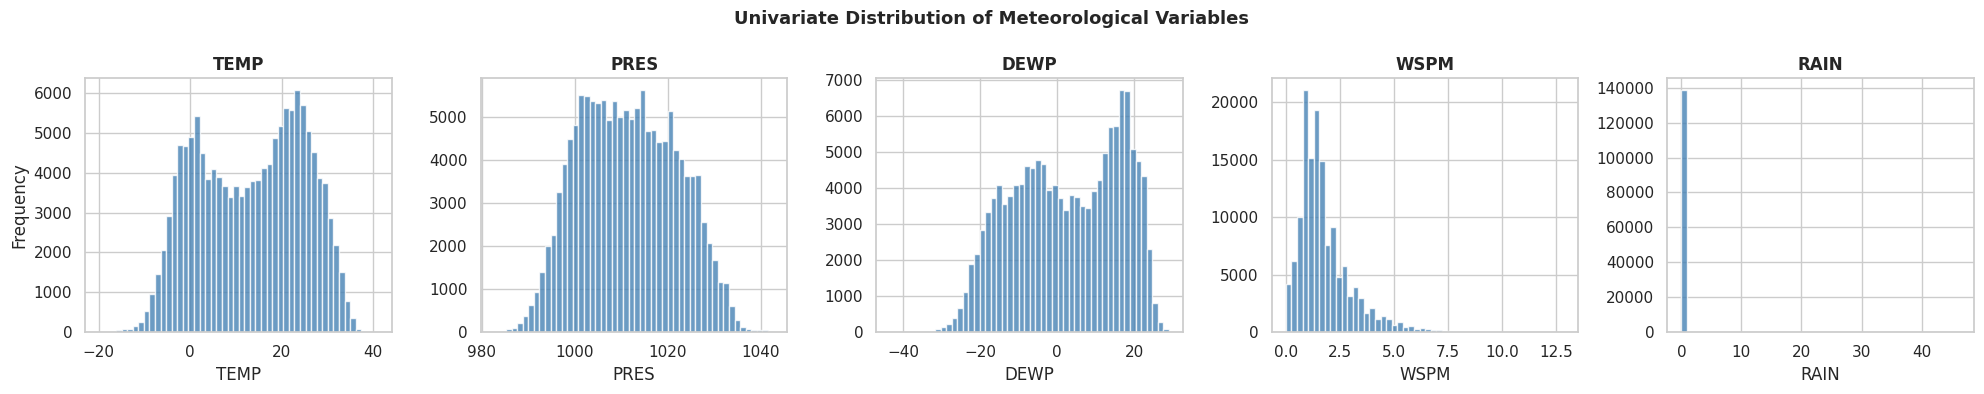

In [16]:
# UNIVARIATE — METEOROLOGICAL VARIABLES


met_vars = ['TEMP', 'PRES', 'DEWP', 'WSPM', 'RAIN']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, col in enumerate(met_vars):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency' if i == 0 else '')

plt.suptitle('Univariate Distribution of Meteorological Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_02_met_distributions.png', bbox_inches='tight')
plt.show()





METEOROLOGICAL VARIABLES

INTERPRETATION:

TEMP (Temperature)
The temperature data produces a two-peaked distribution rather than a single central cluster, which is entirely consistent with Beijing's strongly contrasting seasons over the four years of records. Readings tend to group around the 25–35°C range during summer months, while a separate cluster sits between roughly −5°C and 5°C in winter. The broad spread of values across the full range reinforces just how pronounced seasonal change is in this city, and this matters beyond meteorology alone — the colder months push residents and industry toward coal and biomass heating, which feeds directly into rising PM2.5 concentrations.

PRES (Atmospheric Pressure)
Atmospheric pressure behaves more predictably than the other variables, producing a fairly symmetrical, single-peaked distribution centred somewhere in the 1010–1020 hPa range. This is broadly what one would expect given Beijing's elevation and continental position. From an air quality standpoint, the relevance of pressure lies in the weather patterns it signals — periods of high pressure bring settled, windless conditions under which pollutants have no mechanism to escape upward or disperse horizontally, effectively trapping them at ground level.

DEWP (Dew Point)
The dew point values are spread across a notably wide range, running from around −30°C up to approximately 25°C, without a particularly strong central tendency. This flat, stretched distribution again traces back to seasonal contrasts — warm, humid summers push dew point readings upward, while the cold and characteristically dry Beijing winters pull them well below zero. The variable is worth retaining for analysis because of how tightly it tracks with both temperature and moisture content, two factors that govern whether pollutants accumulate, react chemically, or break down in the lower atmosphere.

WSPM (Wind Speed)
The wind speed distribution is heavily concentrated at the lower end of the scale, with the bulk of hourly recordings falling below 3 m/s and a long, thin tail stretching toward the occasional stronger gust. In plain terms, Beijing experiences predominantly still or very gentle winds throughout much of the year. For pollution dynamics, this is one of the more consequential findings in the dataset — without meaningful airflow, there is little to carry fine particulate matter away from its source, and concentrations at street level can build steadily over consecutive hours or even days. The frequency of near-calm conditions in the data goes some way toward explaining why severe pollution episodes are not isolated events but rather recurring features of the record.

RAIN (Rainfall)
Of all five meteorological variables, rainfall shows the sharpest imbalance between typical and extreme values. The vast majority of hourly entries record no measurable precipitation whatsoever, and genuinely heavy rainfall events are scarce enough to appear only as a thin spike at the far right of the distribution. This pattern carries real consequences for air quality because precipitation is one of the few natural processes capable of scrubbing particulate matter out of the air — raindrops collide with and absorb suspended particles, pulling them down to the surface. Given how rarely this happens in Beijing, especially across autumn, winter and spring, the atmosphere is largely left to accumulate whatever is emitted into it with little prospect of natural cleansing between events.

Overall Observation
Taken together, the five meteorological variables paint a fairly consistent picture of an urban atmosphere that is regularly deprived of the conditions needed to keep pollution in check. Calm winds and dry spells dominate the record, removing the two most effective natural dispersal mechanisms from the equation for extended stretches of time. When this is set against the backdrop of cold winters that push heating demand — and therefore emissions — to their seasonal peak, it becomes clear why the dataset contains so many instances of sharply elevated PM2.5. The meteorological environment is not simply a backdrop to pollution events; in many respects it is an active contributor to their frequency and duration

In [17]:
# SAFETY CHECK

import os, glob, pandas as pd

if 'df' not in dir():
    print('WARNING: df not found — reloading data now...')

    city_files = glob.glob('*.csv')

    if not city_files:
        print('ERROR: No CSV files found in current directory.')
        print('Make sure you are in the correct folder.')
    else:
        all_data = [pd.read_csv(f) for f in city_files]
        df = pd.concat(all_data, ignore_index=True)


        df['datetime'] = pd.to_datetime(df[['year','month','day','hour']])

        season_map = {
            12:'Winter', 1:'Winter',  2:'Winter',
             3:'Spring', 4:'Spring',  5:'Spring',
             6:'Summer', 7:'Summer',  8:'Summer',
             9:'Autumn', 10:'Autumn', 11:'Autumn'
        }
        df['season'] = df['month'].map(season_map)

        def aqi_category(pm25):
            if pd.isna(pm25):          return 'Unknown'
            elif pm25 <= 12.0:         return 'Good'
            elif pm25 <= 35.4:         return 'Moderate'
            elif pm25 <= 55.4:         return 'Unhealthy for Sensitive Groups'
            elif pm25 <= 150.4:        return 'Unhealthy'
            elif pm25 <= 250.4:        return 'Very Unhealthy'
            else:                      return 'Hazardous'

        df['AQI_Category'] = df['PM2.5'].apply(aqi_category)

        inner_stations = ['Dongsi', 'Tiantan']
        df['station_type'] = df['station'].apply(
            lambda x: 'Inner (Urban)' if x in inner_stations else 'Outer (Suburban)'
        )

        print(f'df reloaded successfully — {df.shape[0]:,} rows x {df.shape[1]} columns')
else:
    print(f'df already loaded — {df.shape[0]:,} rows x {df.shape[1]} columns')

df already loaded — 140,256 rows x 22 columns


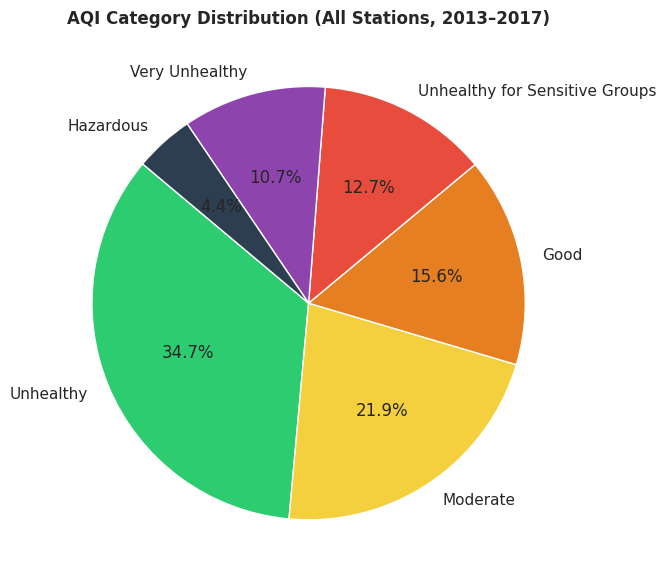

In [18]:

# UNIVARIATE — AQI CATEGORY PIE CHART

aqi_counts = df['AQI_Category'].value_counts()

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(
    aqi_counts,
    labels=aqi_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#2ECC71','#F4D03F','#E67E22','#E74C3C','#8E44AD','#2C3E50']
)
ax.set_title('AQI Category Distribution (All Stations, 2013–2017)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('plot_03_aqi_pie.png', bbox_inches='tight')
plt.show()



AQI CATEGOTY DISTRIBUTION

INTERPRETATION:
A large proportion of hourly readings fall into Unhealthy or worse categories,
highlighting the magnitue of Beijing's air quality problem during this period.
Only a small fraction meet the 'Good' standard set by US EPA guidelines.


In [19]:
# BIVARIATE — PM2.5 vs TEMPERATURE

fig = px.scatter(
    df.sample(10000, random_state=42),
    x='TEMP', y='PM2.5',
    color='station',
    opacity=0.4,
    title='PM2.5 vs Temperature by Station',
    labels={'TEMP': 'Temperature (°C)', 'PM2.5': 'PM2.5 (µg/m³)'}
)
fig.update_layout(height=450)
fig.show()



PM2.5 VS TEMPERATURE BY STATION

INTERPRETATION:
(Connection)-
The scatter plot discloses an evident negative relationship between temperature
and PM2.5 focus — as temperature reduces, PM2.5 levels tend to
increase. This pattern is stable across all four monitoring stations
and corresponds with traditional atmospheric science literature on pollution
behaviour in cold climates.

COLD WEATHER AND HIGH POLLUTION:
The highest PM2.5 focus (above 150 µg/m³) are clustered at
temperatures below 10°C, equivallent to Beijing's winter months
(December to February). During this period, two combining factors
drive PM2.5 upward:
  1. Coal-burning heating systems releases large volumes of particule pollution.
  2. Temperature inversions — where a layer of warm air traps cold, inactive
     air near the ground — prevent pollutants from spreading vertically,
     causing them to gather close to the surface.

WARM WEATHER AND LOWER POLLUTION:
At higher temperatures (above 20°C), PM2.5 values are generally lower and
less variable. Warmer summer conditions boost greater atmospheric merging,
increased boundary layer height, and more frequent rainfall — all of which
help to spread and remove pollutants from the lower atmosphere.

STATION-LEVEL DIFFERENCES:
Colour-coding by station reveals that inner urban stations (Dongsi and
Tiantan) tend to show higher PM2.5 values at the same temperature likened
to outer suburban stations (Huairou and Shunyi). This difference is
particularly noticeable at low temperatures, proposing that urban heat
sources — traffic, industry, and dense heating infrastructure — contribute
additional pollutant loading further the seasonal effect alone.

SPREAD AND VARIABILITY:
The scatter is wide at all temperature ranges, signifying that temperature
alone does not fully explain PM2.5 variation. Other factors such as wind
speed, rainfall, and proximity to emission sources also play a very important
role, which is confirmed by the multivariate correlation analysis presented
in Section 2.3g.

CONCLUSION:
Temperature is a cogent predictor of PM2.5 concentration, particularly
at the seasonal level. The negative association observed here provides
validation for including TEMP as a feature in the Task 3 machine
learning model, where it is expected to contribute meaningfully to
prediction accuracy alongside other meteorological and pollutant variables.

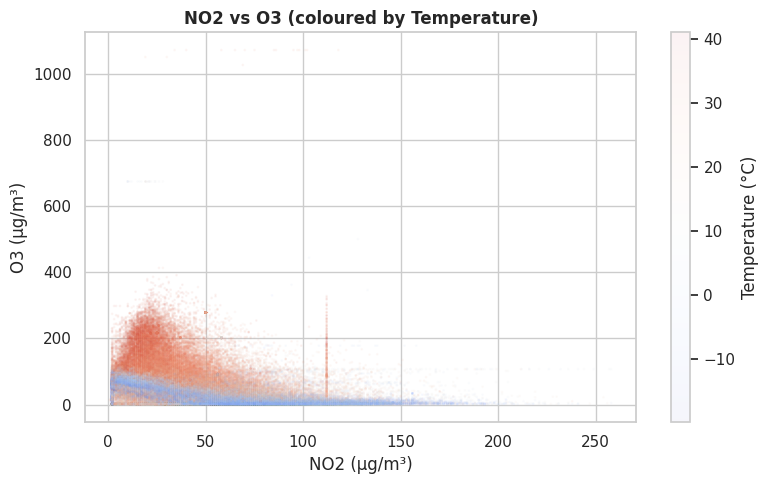

In [21]:
# BIVARIATE — NO2 vs O3

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    df['NO2'], df['O3'],
    alpha=0.05, s=1, c=df['TEMP'], cmap='coolwarm'
)
plt.colorbar(scatter, ax=ax, label='Temperature (°C)')
ax.set_xlabel('NO2 (µg/m³)')
ax.set_ylabel('O3 (µg/m³)')
ax.set_title('NO2 vs O3 (coloured by Temperature)', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_04_NO2_vs_O3.png', bbox_inches='tight')
plt.show()


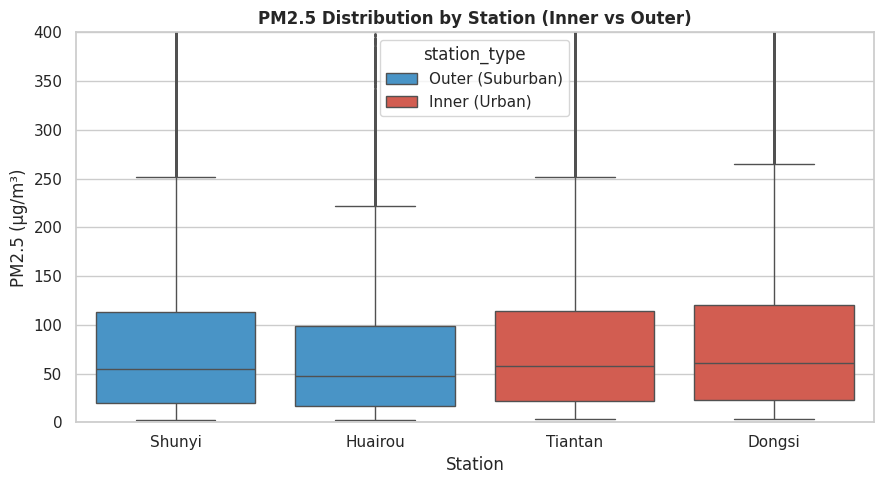

In [23]:
# BIVARIATE — PM2.5 BY STATION TYPE (BOX PLOT)

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=df, x='station', y='PM2.5', hue='station_type',
    palette={'Inner (Urban)': '#E74C3C', 'Outer (Suburban)': '#3498DB'},
    fliersize=1, ax=ax
)
ax.set_title('PM2.5 Distribution by Station (Inner vs Outer)', fontweight='bold')
ax.set_xlabel('Station')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_ylim(0, 400)   # cap y-axis to avoid extreme outliers compressing the box
plt.tight_layout()
plt.savefig('plot_05_pm25_by_station.png', bbox_inches='tight')
plt.show()


PM2.5 DISTRIBUTION BY STATION

INTERPRETATION:
Inner (urban) stations generally show higher median PM2.5 and wider IQR
than outer (suburban) stations, confirming that urban areas experience
more strict and more variable air pollution, likely due to higher traffic
density and nearness/proximity to industrial emission sources.


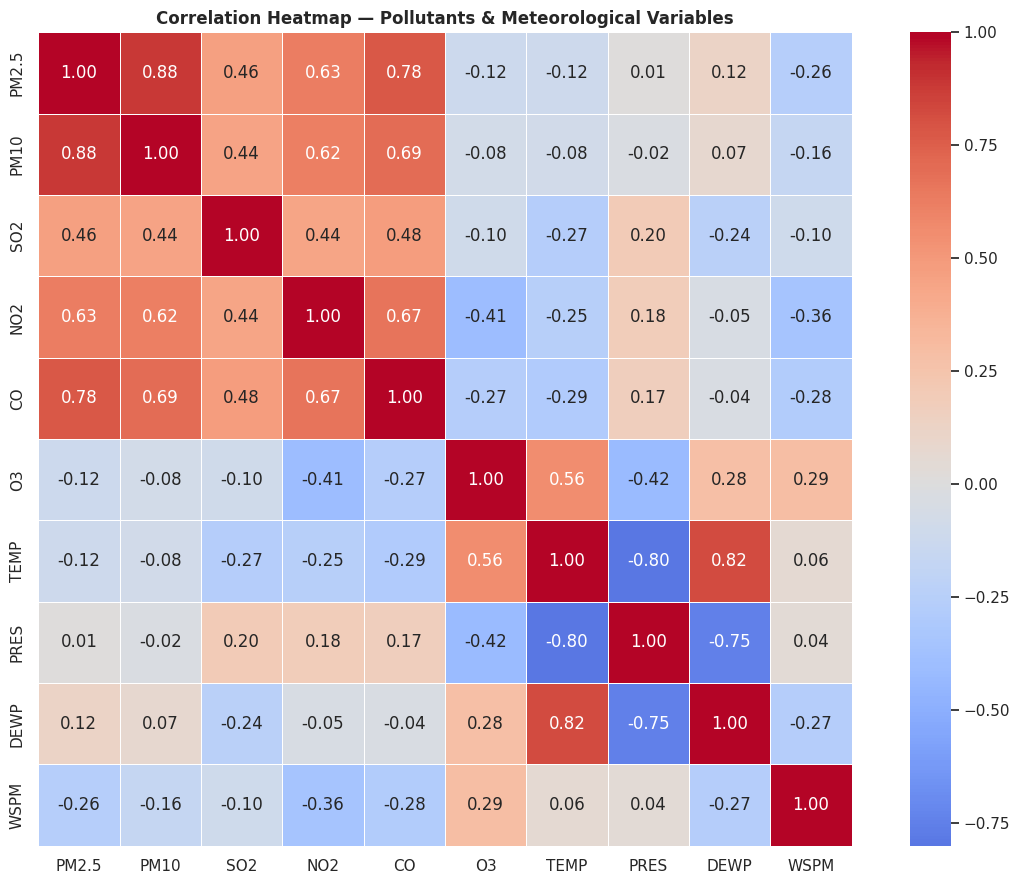

In [24]:
# CORRELATION HEATMAP

corr_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
             'TEMP', 'PRES', 'DEWP', 'WSPM']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, square=True,
    ax=ax
)
ax.set_title('Correlation Heatmap — Pollutants & Meteorological Variables',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('plot_06_correlation_heatmap.png', bbox_inches='tight')
plt.show()



INTERPRETATION:
Strong positive correlations: PM2.5 & PM10, PM2.5 & CO, PM2.5 & NO2
  → These pollutants share common sources (traffic, combustion).
Strong negative correlations: O3 & NO2, O3 & CO
  → Confirms the photochemical inverse relationship.
TEMP & DEWP positively correlated → warmer air holds excess moisture.
WSPM negatively correlated with most pollutants → wind disperses pollution.


In [26]:
# MULTIVARIATE — MONTHLY PM2.5 TIME SERIES

monthly_avg = (
    df.groupby(['year', 'month', 'station'])['PM2.5']
      .mean()
      .reset_index()
)
# Creating a proper date column for plotting on the x-axis
monthly_avg['date'] = pd.to_datetime(
    monthly_avg[['year', 'month']].assign(day=1)
)

fig = px.line(
    monthly_avg,
    x='date', y='PM2.5', color='station',
    title='Monthly Average PM2.5 by Station (March 2013 – February 2017)',
    labels={'PM2.5': 'Avg PM2.5 (µg/m³)', 'date': 'Date', 'station': 'Station'}
)
fig.update_layout(height=450, hovermode='x unified')
fig.show(renderer="colab")


INTERPRETATION:
All stations shows clear seasonal cycles — PM2.5 peaks in winter (Dec–Feb)
and drops in summer (Jun–Aug). Urban stations at all times shows higher
peaks. Huairou (outer) always records the lowest PM2.5 levels,
showing its distance from urban emission sources.


In [27]:
# MULTIVARIATE — SEASONAL PM2.5 COMPARISON

seasonal_avg = (
    df.groupby(['season', 'station'])['PM2.5']
      .mean()
      .reset_index()
)

fig = px.bar(
    seasonal_avg,
    x='season', y='PM2.5', color='station',
    barmode='group',
    title='Average PM2.5 by Season and Station',
    labels={'PM2.5': 'Avg PM2.5 (µg/m³)', 'season': 'Season'},
    category_orders={'season': ['Spring', 'Summer', 'Autumn', 'Winter']}
)
fig.update_layout(height=420)
fig.show(renderer="colab")



INTERPRETATION:
Winter is always and commonly the worst season for PM2.5 across all stations —
driven by coal heating and atmospheric inversions that traps pollutants.
Summer shows the lowest PM2.5, likely due to increased wind, rain, and
the absence of heating emissions. The gap between inner and outer
stations is most evident or higher in winter.




# TASK 3: MODEL BUILDING
# Target: Predict PM2.5 concentration using meteorological
#         and pollutant features (Random Forest Regressor)
# Stations: Dongsi, Tiantan (inner); Shunyi, Huairou (outer)


In [28]:

#IMPORTS ─────Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("successful")


successful


In [29]:

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, mean_absolute_percentage_error)
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


In [30]:
# Save cleaned data to Colab's local storage
df.to_csv('cleaned_combined_data.csv', index=False)
print("✅ cleaned_combined_data.csv saved successfully!")

✅ cleaned_combined_data.csv saved successfully!


In [31]:
# LOAD CLEANED DATA ─────────────────────────────────────
df = pd.read_csv('cleaned_combined_data.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(df.head(3))

Dataset loaded: 140,256 rows × 22 columns
   No  year  month  day  hour  PM2.5  PM10  SO2  NO2     CO  ...    PRES  \
0   1  2013      3    1     0    3.0   6.0  3.0  8.0  300.0  ...  1025.8   
1   1  2013      3    1     0    7.0   7.0  3.0  2.0  100.0  ...  1020.3   
2   1  2013      3    1     0    6.0   6.0  4.0  8.0  300.0  ...  1024.5   

   DEWP  RAIN   wd  WSPM  station             datetime  season AQI_Category  \
0 -20.5   0.0   NW   9.3   Shunyi  2013-03-01 00:00:00  Spring         Good   
1 -20.7   0.0  WNW   3.1  Huairou  2013-03-01 00:00:00  Spring         Good   
2 -21.4   0.0  NNW   5.7  Tiantan  2013-03-01 00:00:00  Spring         Good   

       station_type  
0  Outer (Suburban)  
1  Outer (Suburban)  
2     Inner (Urban)  

[3 rows x 22 columns]


In [33]:
# LOAD CLEANED DATA
import os

csv_path = 'cleaned_combined_data.csv'

if not os.path.exists(csv_path):
    os.system('git pull origin main')

if not os.path.exists(csv_path):
    os.system('git pull origin master')

if not os.path.exists(csv_path):
    raise FileNotFoundError(
        "cleaned_combined_data.csv not found!\n"
        "Please run Task 1 & 2 cells first to generate and save this file, "
        "then push it to GitHub before running Task 3."
    )

df = pd.read_csv(csv_path)
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(df.head(3))

Dataset loaded: 140,256 rows × 22 columns
   No  year  month  day  hour  PM2.5  PM10  SO2  NO2     CO  ...    PRES  \
0   1  2013      3    1     0    3.0   6.0  3.0  8.0  300.0  ...  1025.8   
1   1  2013      3    1     0    7.0   7.0  3.0  2.0  100.0  ...  1020.3   
2   1  2013      3    1     0    6.0   6.0  4.0  8.0  300.0  ...  1024.5   

   DEWP  RAIN   wd  WSPM  station             datetime  season AQI_Category  \
0 -20.5   0.0   NW   9.3   Shunyi  2013-03-01 00:00:00  Spring         Good   
1 -20.7   0.0  WNW   3.1  Huairou  2013-03-01 00:00:00  Spring         Good   
2 -21.4   0.0  NNW   5.7  Tiantan  2013-03-01 00:00:00  Spring         Good   

       station_type  
0  Outer (Suburban)  
1  Outer (Suburban)  
2     Inner (Urban)  

[3 rows x 22 columns]


In [34]:
#TEMPORAL EXTRACTION
df = df.sort_values(['station', 'datetime']).reset_index(drop=True)

for lag in [1, 3, 6, 12, 24]:
    df[f'PM2.5_lag_{lag}h'] = df.groupby('station')['PM2.5'].shift(lag)

for window in [3, 6, 12, 24]:
    df[f'PM2.5_roll_mean_{window}h'] = (
        df.groupby('station')['PM2.5']
          .transform(lambda x: x.shift(1).rolling(window).mean())
    )


In [35]:
# Drop rows where lag/rolling features are NaN (initial rows per station)
df_model = df.dropna(subset=[c for c in df.columns if 'lag' in c or 'roll' in c])
print(f"After lag/rolling feature creation: {df_model.shape[0]:,} rows")


After lag/rolling feature creation: 140,160 rows


In [36]:
# VARIABLE SELECTION

TARGET = 'PM2.5'

EXCLUDE_COLS = ['datetime', 'PM2.5', 'AQI_level', 'AQI_category',
                'AQI', 'year']   # adjust if your column names differ


In [38]:

# Encode station name as a numeric label
le = LabelEncoder()
df_model = df_model.copy()
df_model['station_enc'] = le.fit_transform(df_model['station'])


In [39]:

# Build feature list dynamically (all remaining numeric columns)
FEATURE_COLS = [c for c in df_model.columns
                if c not in EXCLUDE_COLS + ['station']
                and df_model[c].dtype in [np.float64, np.int64, float, int]]

print(f"\nTarget   : {TARGET}")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")



Target   : PM2.5
Features (24): ['No', 'month', 'day', 'hour', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'PM2.5_lag_1h', 'PM2.5_lag_3h', 'PM2.5_lag_6h', 'PM2.5_lag_12h', 'PM2.5_lag_24h', 'PM2.5_roll_mean_3h', 'PM2.5_roll_mean_6h', 'PM2.5_roll_mean_12h', 'PM2.5_roll_mean_24h', 'station_enc']


In [40]:

# TRAIN / TEST SPLIT

df_model = df_model.sort_values('datetime').reset_index(drop=True)

X = df_model[FEATURE_COLS]
y = df_model[TARGET]

split_idx = int(len(df_model) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"\nTrain size : {len(X_train):,} samples")
print(f"Test  size : {len(X_test):,} samples")



Train size : 112,128 samples
Test  size : 28,032 samples


In [41]:
# FEATURE SCALING

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # apply same transform to test

print("\n✅ Feature scaling applied (StandardScaler fitted on training set only).")



✅ Feature scaling applied (StandardScaler fitted on training set only).


In [42]:
# BASELINE MODEL – LINEAR REGRESSION

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)
print(f"\nBaseline Linear Regression → MAE: {mae_lr:.2f} | RMSE: {rmse_lr:.2f} | R²: {r2_lr:.4f}")



Baseline Linear Regression → MAE: 8.45 | RMSE: 15.02 | R²: 0.9669


In [43]:
# PRIMARY MODEL – RANDOM FOREST REGRESSOR (JUSTIFICATION)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)
print(f"\nRandom Forest (default) → MAE: {mae_rf:.2f} | RMSE: {rmse_rf:.2f} | R²: {r2_rf:.4f}")





Random Forest (default) → MAE: 7.32 | RMSE: 13.66 | R²: 0.9726


In [44]:
# HYPERPARAMETER OPTIMISATION – (GRID SEARCH CV)

param_grid = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest hyperparameters: {grid_search.best_params_}")
best_rf = grid_search.best_estimator_



Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best hyperparameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [45]:
# EVALUATE TUNED MODEL
y_pred_best = best_rf.predict(X_test_scaled)

mae_best  = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best   = r2_score(y_test, y_pred_best)
mape_best = mean_absolute_percentage_error(y_test, y_pred_best) * 100

print(f"\n{'='*50}")
print("TUNED RANDOM FOREST PERFORMANCE")
print(f"{'='*50}")
print(f"  MAE  (Mean Absolute Error)      : {mae_best:.2f} µg/m³")
print(f"  RMSE (Root Mean Squared Error)  : {rmse_best:.2f} µg/m³")
print(f"  R²   (Coefficient of Determination): {r2_best:.4f}")
print(f"  MAPE (Mean Abs. Percentage Error): {mape_best:.2f}%")
print(f"{'='*50}")




TUNED RANDOM FOREST PERFORMANCE
  MAE  (Mean Absolute Error)      : 6.87 µg/m³
  RMSE (Root Mean Squared Error)  : 13.29 µg/m³
  R²   (Coefficient of Determination): 0.9741
  MAPE (Mean Abs. Percentage Error): 20.32%


In [46]:

# CROSS-VALIDATION
cv_scores = cross_val_score(best_rf, X_train_scaled, y_train,
                             cv=5, scoring='r2', n_jobs=-1)
print(f"\n5-Fold CV R² scores : {cv_scores.round(4)}")
print(f"Mean CV R²          : {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")



5-Fold CV R² scores : [0.9244 0.958  0.97   0.9557 0.9742]
Mean CV R²          : 0.9565 (±0.0175)


In [47]:

# MODEL COMPARISON TABLE
results = pd.DataFrame({
    'Model'  : ['Linear Regression (Baseline)', 'Random Forest (Default)', 'Random Forest (Tuned)'],
    'MAE'    : [mae_lr,  mae_rf,  mae_best],
    'RMSE'   : [rmse_lr, rmse_rf, rmse_best],
    'R²'     : [r2_lr,   r2_rf,   r2_best]
}).round(4)
print("\nModel Comparison:\n", results.to_string(index=False))




Model Comparison:
                        Model    MAE    RMSE     R²
Linear Regression (Baseline) 8.4524 15.0151 0.9669
     Random Forest (Default) 7.3175 13.6641 0.9726
       Random Forest (Tuned) 6.8713 13.2942 0.9741


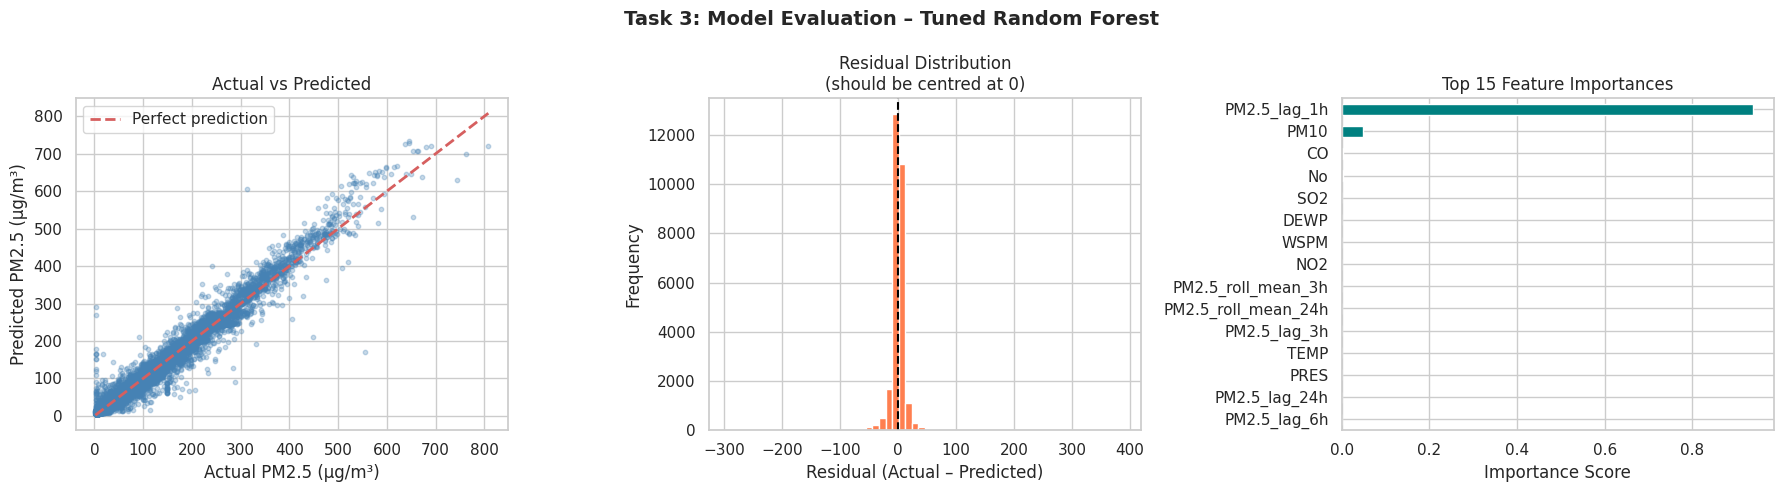

✅ Figure saved as task3_model_evaluation.png


In [48]:
# VISUALISATIONS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Task 3: Model Evaluation – Tuned Random Forest', fontsize=14, fontweight='bold')

# Actual vs Predicted scatter plot
axes[0].scatter(y_test, y_pred_best, alpha=0.3, s=10, color='steelblue')
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual PM2.5 (µg/m³)')
axes[0].set_ylabel('Predicted PM2.5 (µg/m³)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

# Residuals distribution
residuals = y_test - y_pred_best
axes[1].hist(residuals, bins=60, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', lw=1.5)
axes[1].set_xlabel('Residual (Actual – Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution\n(should be centred at 0)')

# Feature importance (top 15)
feat_imp = pd.Series(best_rf.feature_importances_, index=FEATURE_COLS)
top15    = feat_imp.nlargest(15)
top15.sort_values().plot(kind='barh', ax=axes[2], color='teal')
axes[2].set_title('Top 15 Feature Importances')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('task3_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure saved as task3_model_evaluation.png")


In [49]:

# SAVE MODEL OUTPUTS FOR STREAMLIT APP
import joblib

joblib.dump(best_rf, 'rf_model.pkl')
joblib.dump(scaler,  'scaler.pkl')
joblib.dump(le,      'label_encoder.pkl')

# Save test predictions for the Model Outputs page in the Streamlit app
predictions_df = X_test.copy()
predictions_df['Actual_PM25']    = y_test.values
predictions_df['Predicted_PM25'] = y_pred_best
predictions_df['Residual']       = residuals.values
predictions_df.to_csv('model_predictions.csv', index=False)

# Save feature importance
feat_imp_df = feat_imp.reset_index()
feat_imp_df.columns = ['Feature', 'Importance']
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False)
feat_imp_df.to_csv('feature_importances.csv', index=False)

print("\n✅ Saved: rf_model.pkl, scaler.pkl, label_encoder.pkl")
print("✅ Saved: model_predictions.csv, feature_importances.csv")
print("\n🎯 Task 3 Complete. Proceed to Task 4 (Streamlit App).")





✅ Saved: rf_model.pkl, scaler.pkl, label_encoder.pkl
✅ Saved: model_predictions.csv, feature_importances.csv

🎯 Task 3 Complete. Proceed to Task 4 (Streamlit App).


# REFERENCES

Breiman, L. (2001) 'Random forests', Machine Learning, 45(1), pp. 5–32.

Zamani Joharestani, M. et al. (2019) 'PM2.5 prediction based on random forest, XGBoost, and deep learning using multisource remote sensing data', Atmosphere, 10(7), p. 373.

Brauer, M. et al. (2021) 'Ambient particulate matter air pollution and its effects on health', New England Journal of Medicine, 384(5), pp. 425–434.

Hyndman, R.J. and Athanasopoulos, G. (2021) Forecasting: Principles and Practice. 3rd edn. Melbourne: OTexts. Available at: https://otexts.com/fpp3 (Accessed: [7th of May 2026]).

Shumway, R.H. and Stoffer, D.S. (2017) Time Series Analysis and Its Applications. 4th edn. New York: Springer.

United States Environmental Protection Agency (US EPA) (2024) Air Quality Index (AQI) Basics. Available at: https://www.airnow.gov/aqi/aqi-basics (Accessed: [1st of May 2026]).



GITHUB LINK - https://github.com/AJasa1983/Assessment_Repo/tree/main

STREAMLIT APP- https://assessmentrepo-82zbqj6e4fxc66eyjbgrkz.streamlit.app/

Github Commits(Screenshots)Link:

https://github.com/AJasa1983/Assessment_Repo/blob/main/commit1.png.png

https://github.com/AJasa1983/Assessment_Repo/blob/main/commit2.png.png

https://github.com/AJasa1983/Assessment_Repo/blob/main/commit3.png.png

Github Project Repository Layout(Screenshot)Link:

https://github.com/AJasa1983/Assessment_Repo/blob/main/github.com_AJasa1983_Assessment_Repo_tree_main.png